In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
problems = ["nguyen_9", "nguyen_10", "nguyen_12", "nguyen_9_12"]
seeds = range(0, 5)
algorithms = ["ga", "gomea"]
solvers = ["cgp", "lgp"]

dfs = []
for pop in ["small", "large"]:  #, "diverse"]:
    div = "_large_pop" if pop == "large" else ("_diversity" if pop == "diverse" else "")
    for solver in solvers:
        for algorithm in algorithms:
            for problem in problems:
                for seed in seeds:
                    for dense in [True]:
                        processed_problem = f"{problem}_dense" if dense else problem
                        if algorithm == "gomea":
                            for fos in ["U", "RT", "LT", "LT1"]:  #, "N1", "N2"]:
                                try:
                                    tmp_df = pd.read_csv(
                                        f"../results/{algorithm}_{solver}_{processed_problem}_{fos}_{seed}_fi{div}.csv", )
                                except FileNotFoundError as e:
                                    tmp_df = pd.read_csv(
                                        f"../results/{algorithm}_{solver}_{processed_problem}_{fos}_{seed + 5}_fi{div}.csv", )
                                tmp_df["seed"] = seed
                                tmp_df["algorithm"] = f"{algorithm}_{fos}"
                                tmp_df["problem"] = problem
                                tmp_df["solver"] = solver
                                tmp_df["pop"] = pop
                                tmp_df["n_points"] = 200 if dense else 20
                                dfs.append(tmp_df)
                        else:
                            if pop == "diverse":
                                continue
                            try:
                                tmp_df = pd.read_csv(
                                    f"../results/{algorithm}_{solver}_{processed_problem}_{seed}{div}.csv", )
                            except FileNotFoundError as e:
                                tmp_df = pd.read_csv(
                                    f"../results/{algorithm}_{solver}_{processed_problem}_{seed + 5}{div}.csv")
                            tmp_df["seed"] = seed
                            tmp_df["algorithm"] = algorithm
                            tmp_df["problem"] = problem
                            tmp_df["solver"] = solver
                            tmp_df["pop"] = pop
                            tmp_df["n_points"] = 200 if dense else 20
                            dfs.append(tmp_df)
regression_df = pd.concat(dfs, ignore_index=True)
regression_df.head()

,evaluation,fitness,test_accuracy,uniqueness,time,seed,algorithm,problem,solver,pop,n_points
0,100,0.486215,0.450068,1.0,1.50,0,ga,nguyen_9,cgp,small,200
1,190,0.486215,0.450068,1.0,0.99,0,ga,nguyen_9,cgp,small,200
2,280,0.486215,0.450068,1.0,0.23,0,ga,nguyen_9,cgp,small,200
3,370,0.486215,0.450068,1.0,0.23,0,ga,nguyen_9,cgp,small,200
4,460,0.486215,0.450068,1.0,0.23,0,ga,nguyen_9,cgp,small,200


In [3]:
rounding_factor = 1000
regression_df["rounded_evaluation"] = (regression_df["evaluation"] / rounding_factor).round() * rounding_factor

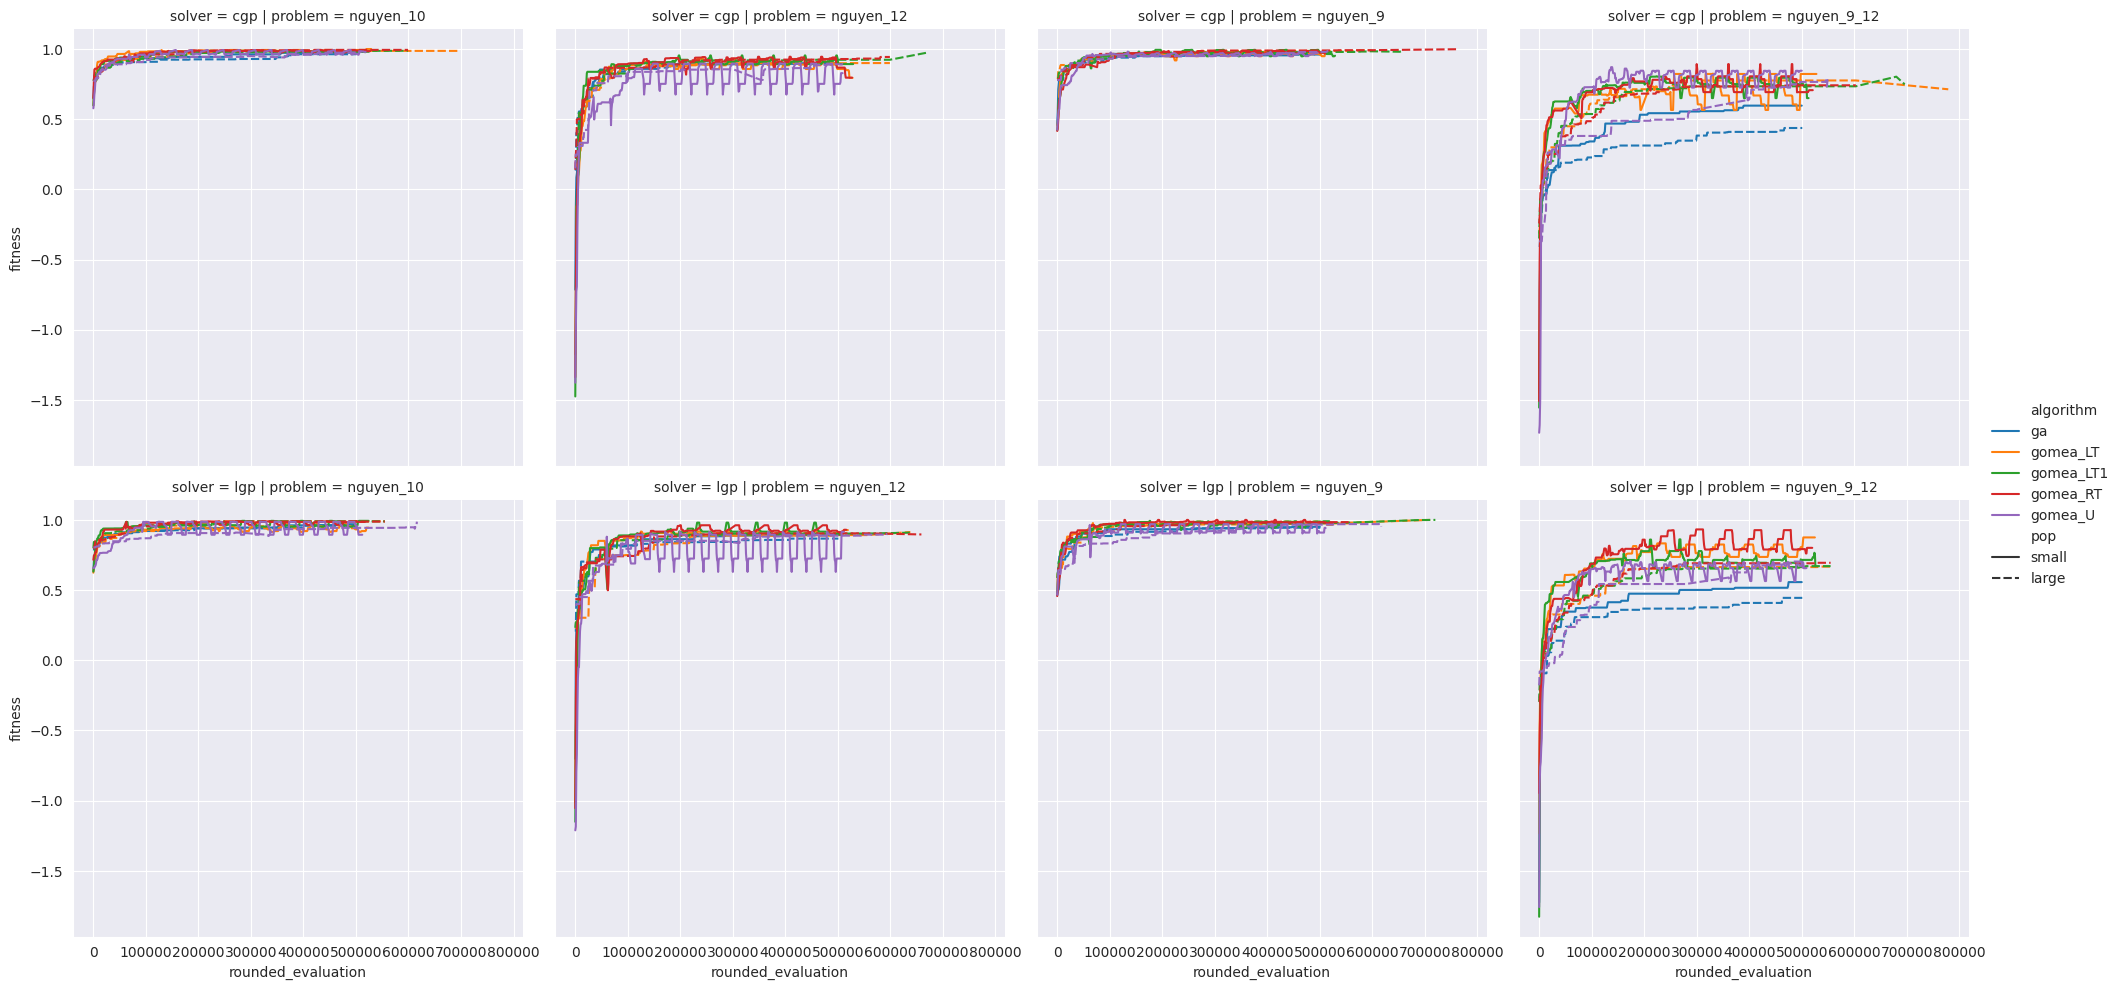

In [4]:
agg_df = (
    regression_df
    .groupby(["rounded_evaluation", "problem", "algorithm", "solver", "n_points", "pop"])
    .mean()
    .reset_index()
)
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="fitness",
    col="problem",
    row="solver",
    hue="algorithm",
    style="pop",
    kind="line",
)
plt.show()

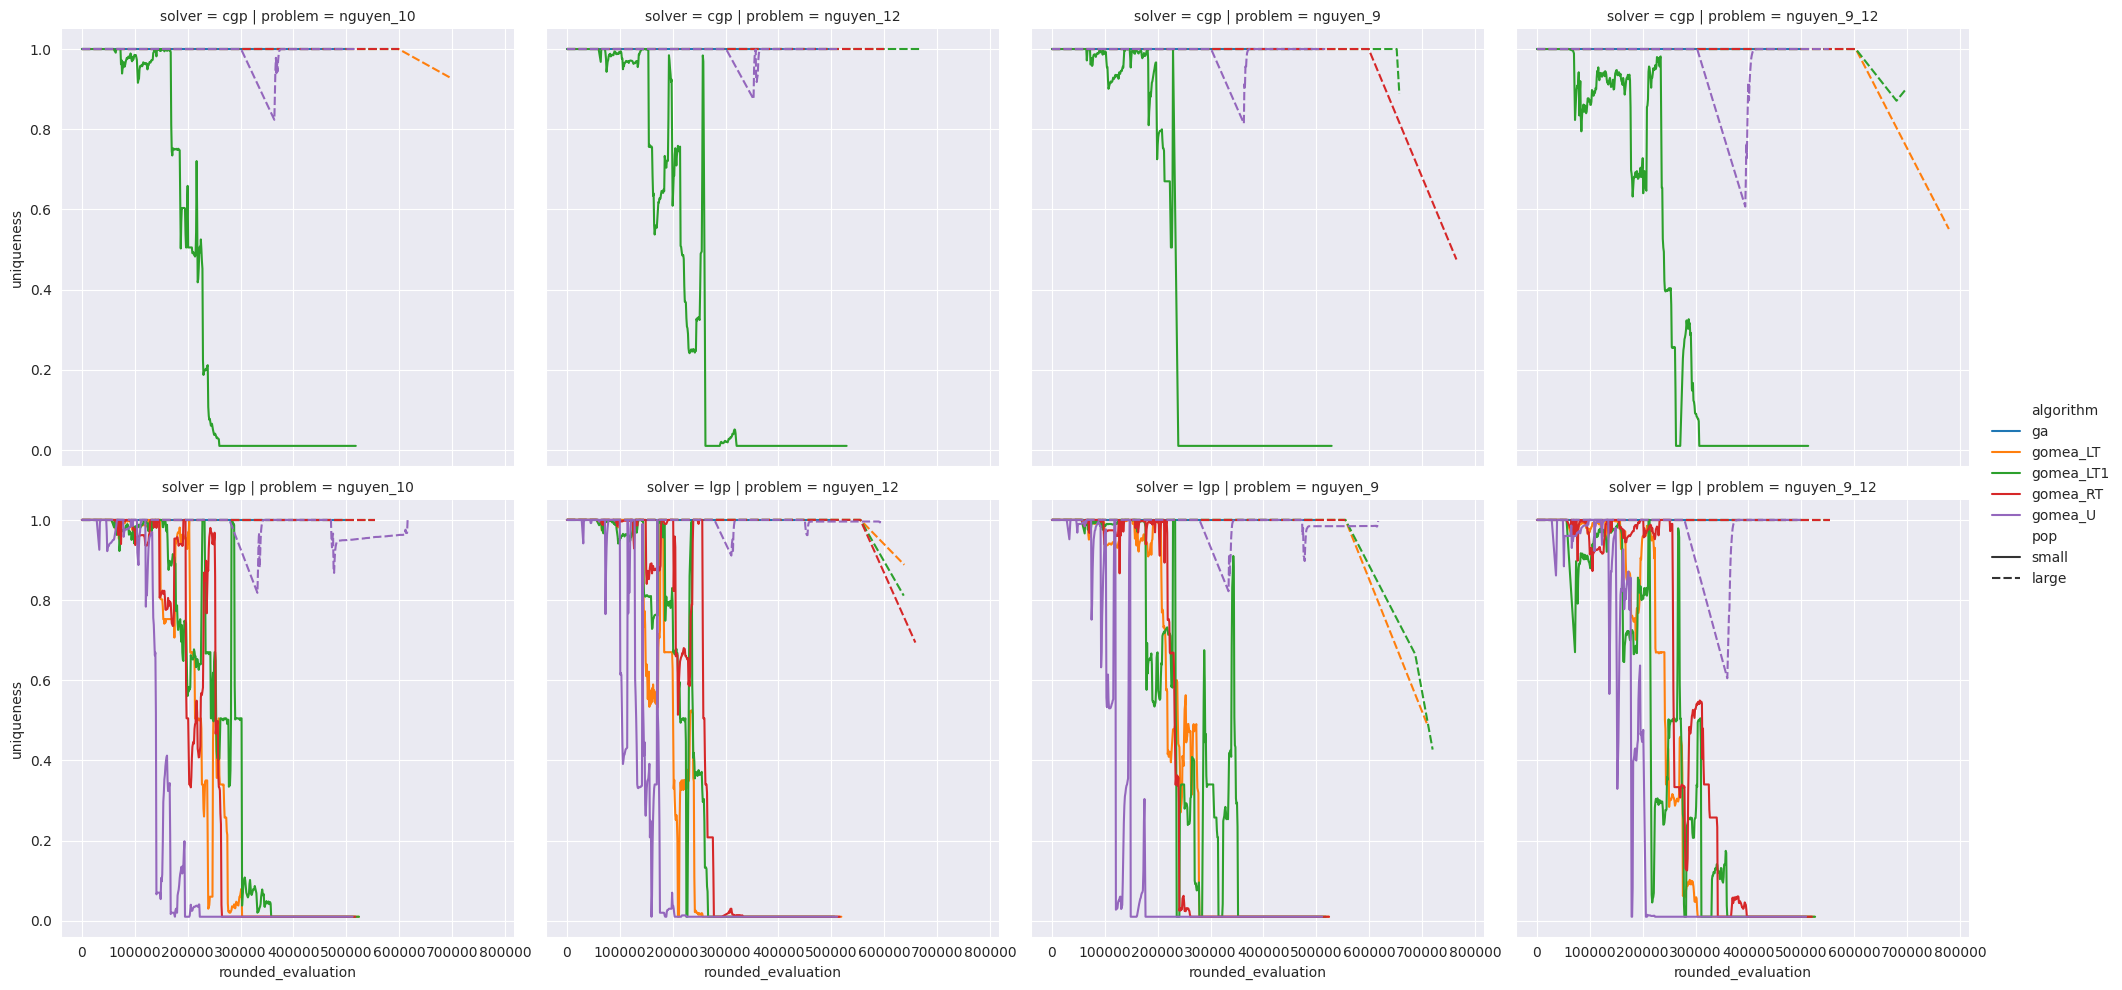

In [5]:
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="uniqueness",
    col="problem",
    row="solver",
    style="pop",
    hue="algorithm",
    kind="line",
)
plt.show()

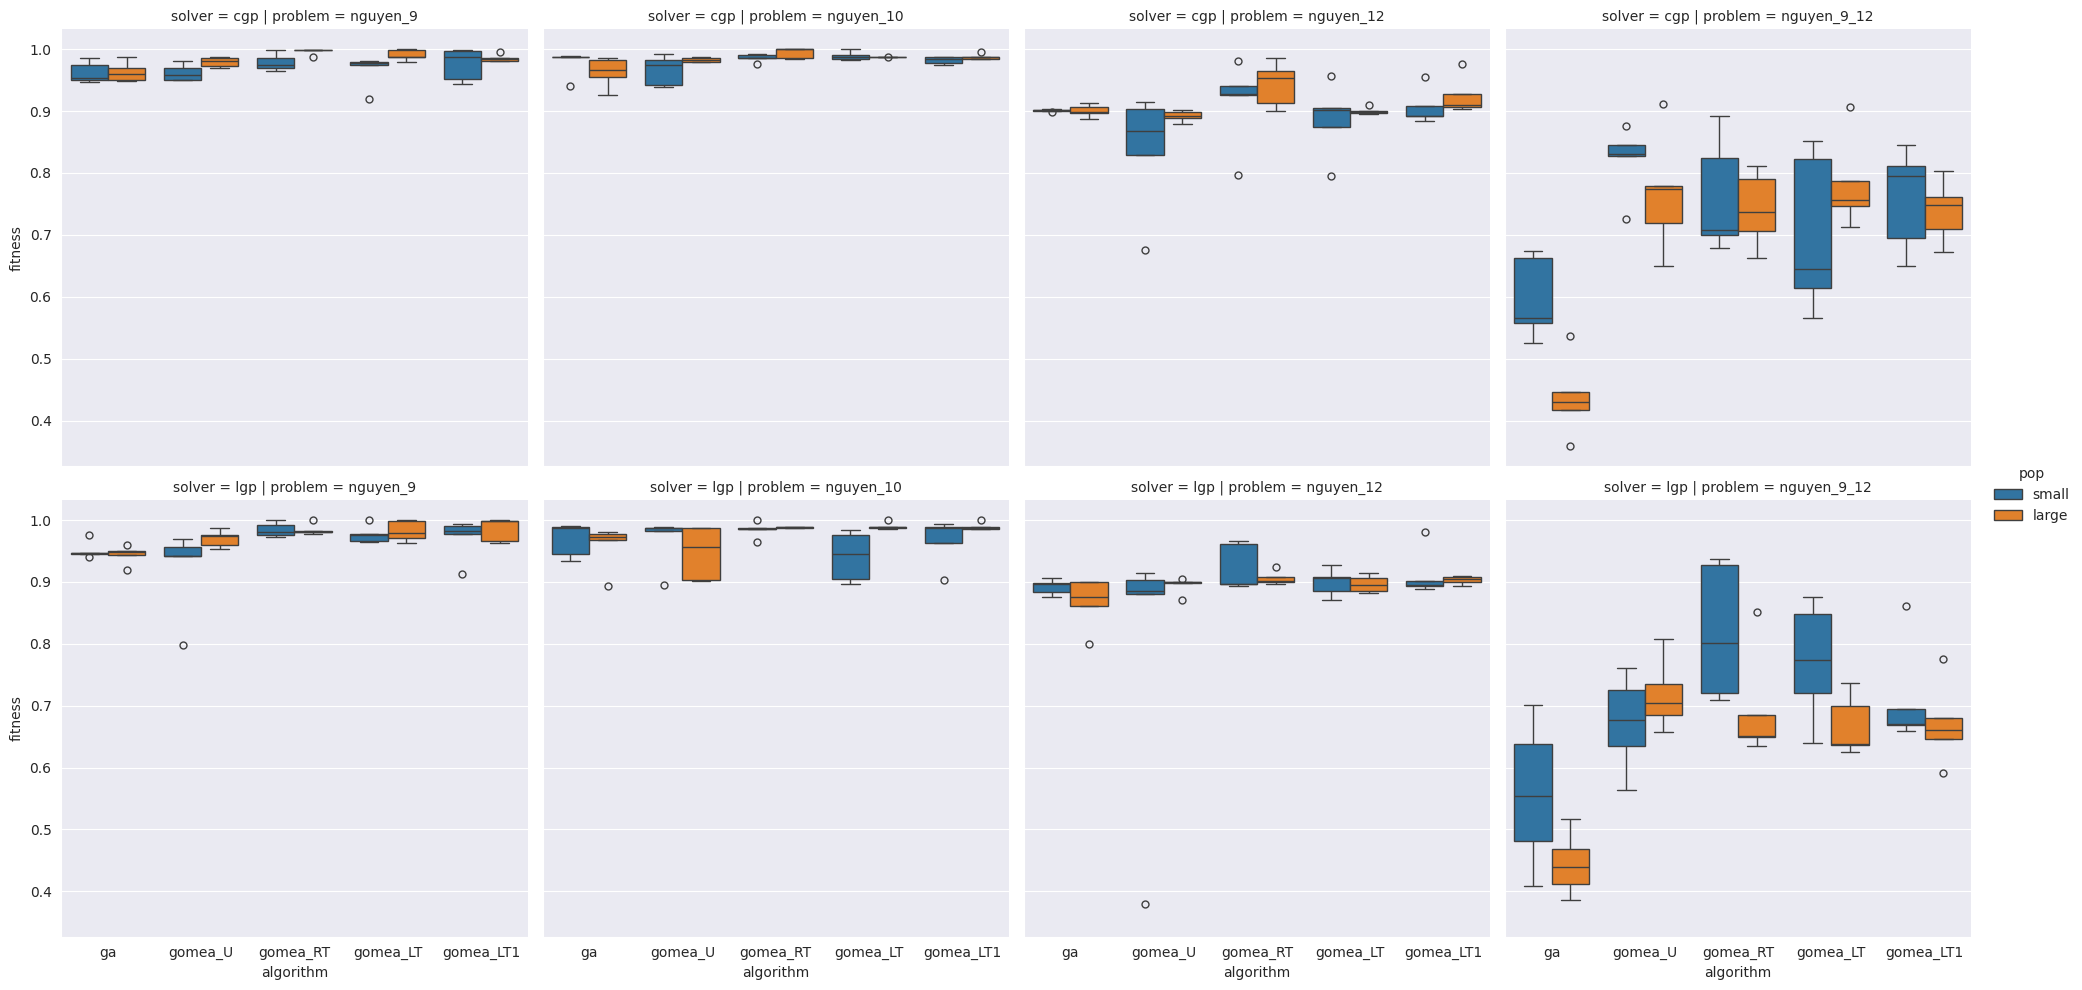

In [6]:
regression_df["max_eval"] = regression_df.groupby(["algorithm", "solver", "problem", "seed", "pop"])[
    "evaluation"].transform("max")
final_regression_df = regression_df[regression_df["evaluation"] == regression_df["max_eval"]].drop(columns="max_eval")
sns.catplot(
    data=final_regression_df, x='algorithm', y='fitness', hue="pop",
    col='problem', kind='box', row='solver',
)
# plt.ylim(0, 1.1)
plt.show()

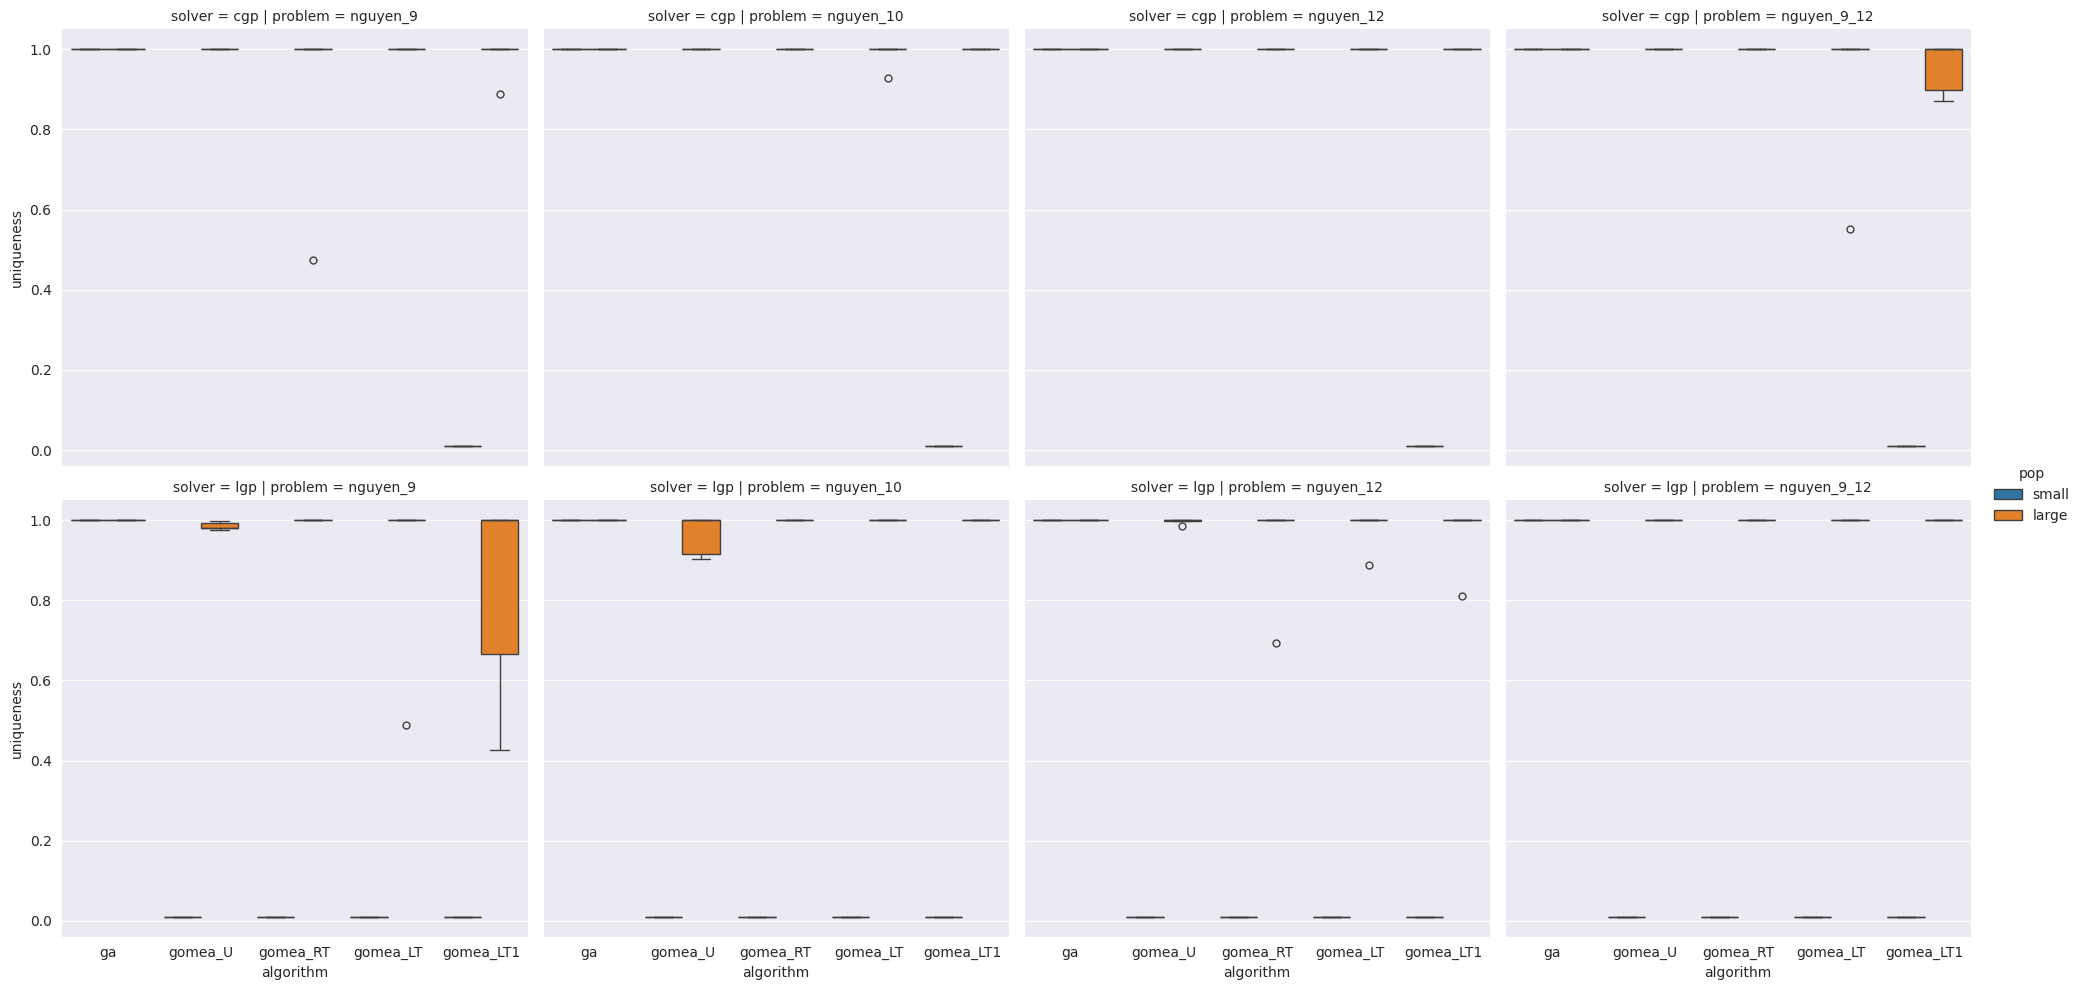

In [7]:
sns.catplot(
    data=final_regression_df, x='algorithm', y='uniqueness', hue="pop",
    col='problem', kind='box',  row='solver',
)
plt.show()

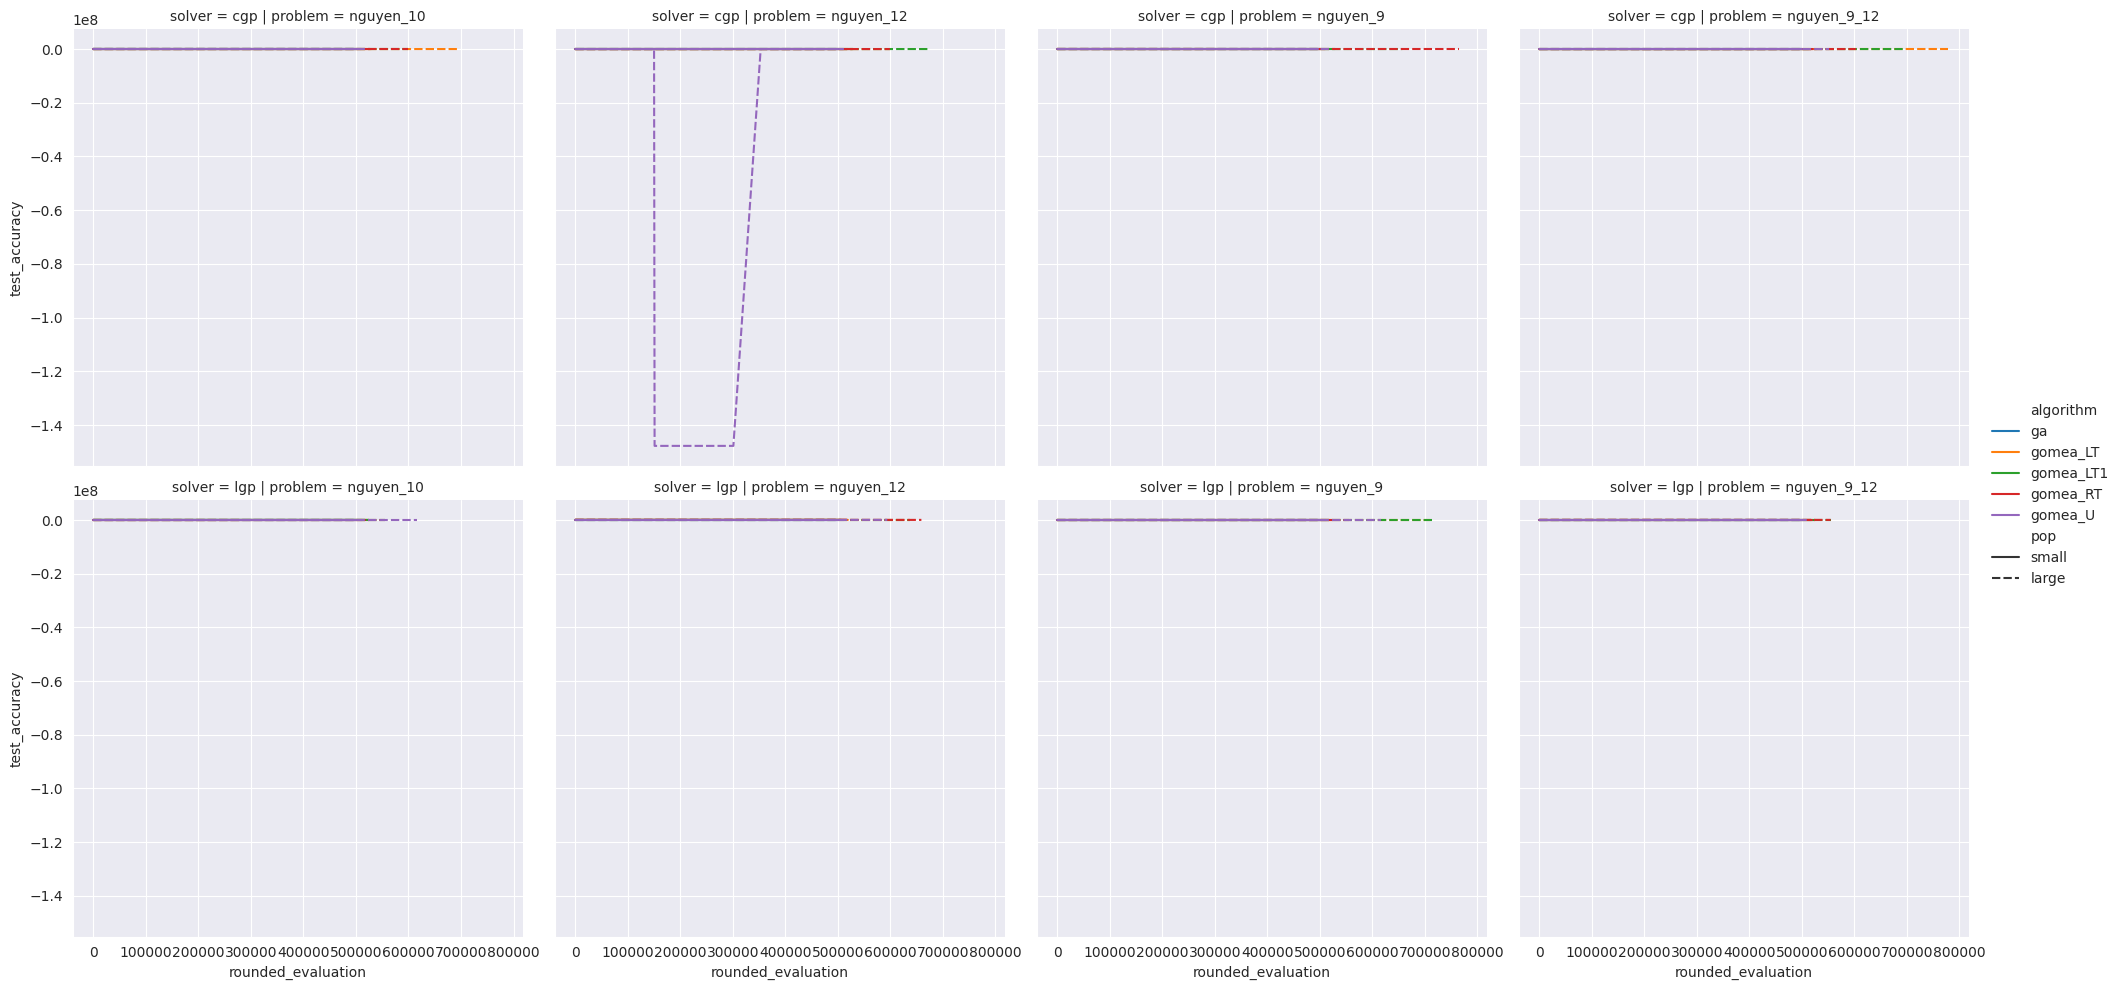

In [8]:
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="test_accuracy",
    col="problem",
    row="solver",
    hue="algorithm",
    style="pop",
    kind="line",
)
plt.show()

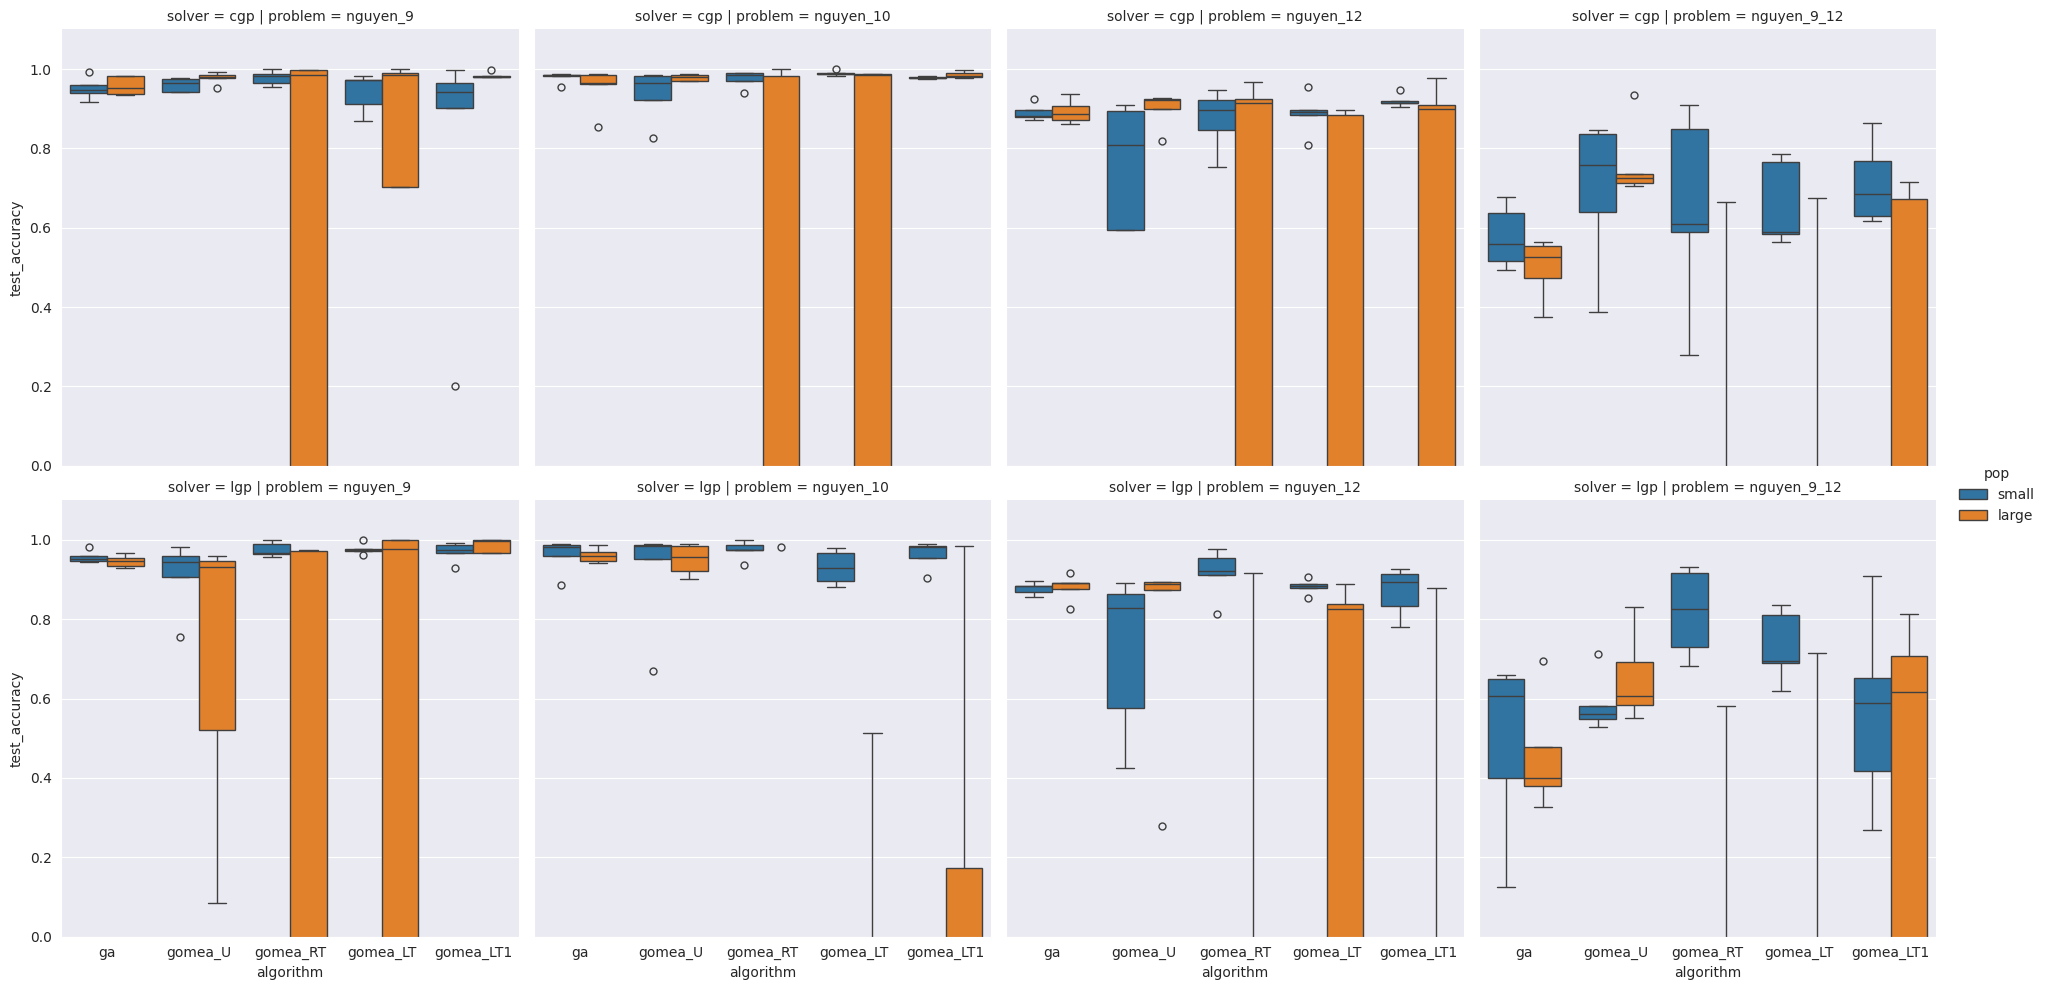

In [9]:
sns.catplot(
    data=final_regression_df, x='algorithm', y='test_accuracy', hue="pop",
    col='problem', kind='box', row="solver",
)
plt.ylim(0, 1.1)
plt.show()

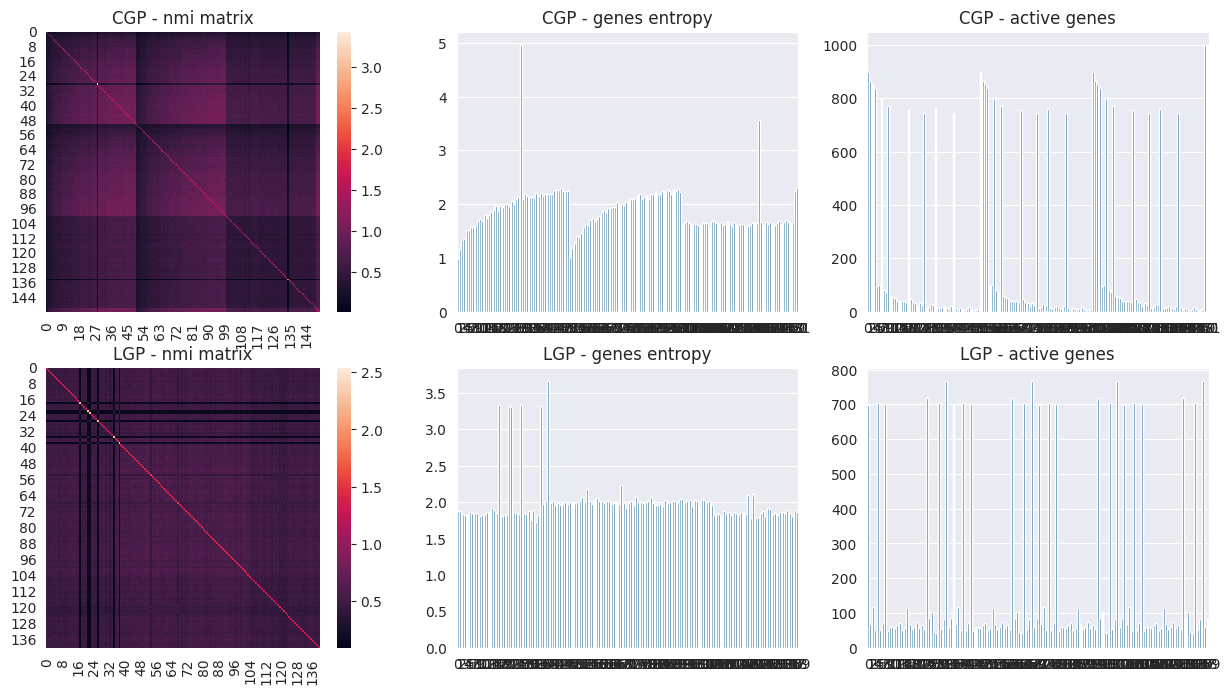

In [16]:
import jax.numpy as jnp

seed = 0
environment = "nguyen_9_12_dense"
pop_type = "_large_pop"
solvers = ["cgp", "lgp"]

fig, axs = plt.subplots(2, 3)
fig.set_figwidth(15)
fig.set_figheight(8)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[solver_idx, 0])
    axs[solver_idx, 0].set_title(f'{solver.upper()} - nmi matrix')
    sns.barplot(unique_genes, ax=axs[solver_idx, 1])
    axs[solver_idx, 1].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[solver_idx, 2])
    axs[solver_idx, 2].set_title(f'{solver.upper()} - active genes')
plt.show()